In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
import seaborn as sns
import matplotlib as mpl
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.dates as mdates
from matplotlib.lines import Line2D

In [36]:
sns.set_theme(
    style="white",
    font="Liberation Sans"
)

plt.rcParams.update({
    'font.family': 'Liberation Sans',  
    'font.size': 22,
    'axes.titlesize': 22,
    'axes.labelsize': 22,
    'xtick.labelsize': 22,
    'ytick.labelsize': 22,
    'legend.fontsize': 22,
    'figure.titlesize': 22,
    'text.color': "#3F3F3FD8",
    'axes.labelcolor': "#3F3F3FD8",
    'xtick.color': "#3F3F3FD8",
    'ytick.color': "#3F3F3FD8",
    'font.weight': 700, 
    'axes.labelweight': 700,
    'axes.titleweight': 700,
})

format = 'png' 
OUTPUT_DIR = "../reports/figures"

In [37]:
DATA_DIR = Path("../data/processed/")
TOPICS_PATH = Path("messages_classified_topics")
TOXICITY_PATY = Path("toxicity_political")

OUTPUT_TOX_DIR = "../reports/toxicity"

In [38]:
PRIMARY_KEY = ["id", "group_name"]

COLS_TOX = [
    *PRIMARY_KEY,
    "toxicity",
    "severe_toxicity",
    "obscene",
    "threat",
    "insult",
    "identity_attack"
]

In [20]:
df_tox = pd.read_parquet(DATA_DIR / TOXICITY_PATY, columns=COLS_TOX)
print(f"Quantidade de mensagens do arquivo de toxicidade: {len(df_tox)}")

df_mod = pd.read_parquet(DATA_DIR / TOPICS_PATH)
print(f"Quantidade de mensagens do arquivo de modelagem: {len(df_mod)}")

Quantidade de mensagens do arquivo de toxicidade: 14788448
Quantidade de mensagens do arquivo de modelagem: 14788448


In [21]:
df = pd.merge(df_mod, df_tox, on = PRIMARY_KEY, how = "inner")
print(f"Shape do df resultando do merge entre os arquivos de modelagem e toxicidade {df.shape}")

Shape do df resultando do merge entre os arquivos de modelagem e toxicidade (14788448, 14)


In [31]:
df['macro_topic_norm'] = df['macro_topic'].str.replace('_', ' ').str.title()
df['datetime'] = pd.to_datetime(df['datetime'])

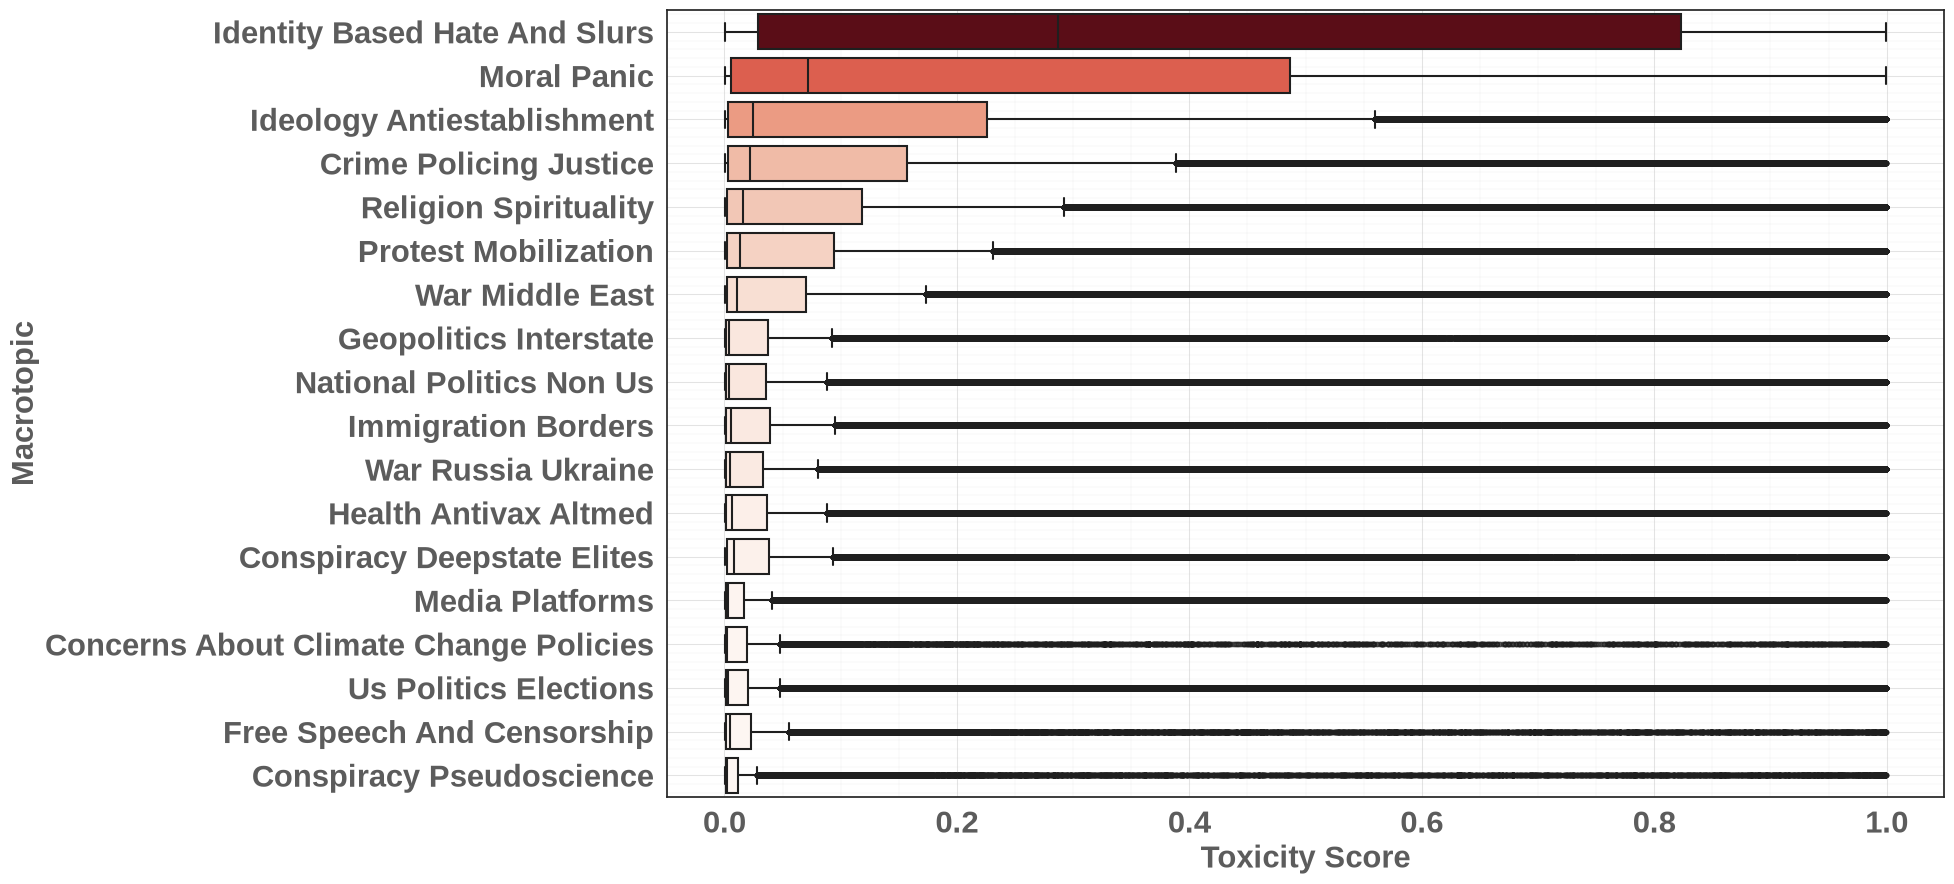

In [29]:
media_toxicidade = (
    df.groupby('macro_topic_norm')['toxicity']
      .mean()
)

# Ordem dos tópicos pela mediana, como você já fazia
ordem_decrescente = (
    df.groupby('macro_topic_norm')['toxicity']
      .mean()
      .sort_values(ascending=False)
      .index
)

# Normalização dos valores de média
norm = Normalize(
    vmin=media_toxicidade.min(),
    vmax=media_toxicidade.max()
)

# Mapa de cores
cmap = plt.cm.Reds

# Cor de cada macrotópico de acordo com a média
palette = {
    topic: cmap(norm(media_toxicidade[topic]))
    for topic in ordem_decrescente
}

plt.figure(figsize=(20, 10))

ax = sns.boxplot(
    x='toxicity',  
    y='macro_topic_norm',
    data=df,
    palette=palette,
    order=ordem_decrescente,
    legend=False,
    hue='macro_topic_norm',
    linewidth=1.5,
    flierprops=dict(
        marker='o',
        markersize=3,
        alpha=0.2
    )
)

ax.set_axisbelow(True)
ax.grid(True,which='major',linestyle='-',linewidth=0.75,alpha=0.55)

ax.minorticks_on()
ax.grid(True,which='minor',linestyle='-',linewidth=0.25,alpha=0.45)

plt.xlabel('Toxicity Score')
plt.ylabel('Macrotopic')

plt.tight_layout(rect=[0, 0, 1, 0.93])

plt.savefig(
    f"{OUTPUT_DIR}/boxplot_toxicity.{format}",
    format=format,
    bbox_inches='tight'
)

plt.show()

In [30]:
import json

# Dicionário que vai armazenar os resultados
resultados_toxicidade = {}

# Selecionar as colunas que queremos levar para o JSON
colunas_interesse = ['id', 'group_name', 'clean_text', 'toxicity']

# Iterar sobre cada macrotópico normalizado
topicos = df['macro_topic_norm'].dropna().unique()

print("Extraindo mensagens...")
for topico in topicos:
    # Filtra o dataframe para o tópico atual
    df_topico = df[df['macro_topic_norm'] == topico]
    
    # Extrai as 10 mais tóxicas e as 10 menos tóxicas
    mais_toxicas = df_topico.nlargest(10, 'toxicity')[colunas_interesse]
    menos_toxicas = df_topico.nsmallest(10, 'toxicity')[colunas_interesse]
    
    # Converte para lista de dicionários
    resultados_toxicidade[topico] = {
        "mais_toxicas": mais_toxicas.to_dict(orient='records'),
        "menos_toxicas": menos_toxicas.to_dict(orient='records')
    }

# Caminho para salvar o arquivo
caminho_json = f"{OUTPUT_TOX_DIR}/extremos_toxicidade.json"

# Salvar em formato JSON garantindo a acentuação correta
with open(caminho_json, 'w', encoding='utf-8') as f:
    json.dump(resultados_toxicidade, f, ensure_ascii=False, indent=4)

print(f"Sucesso! O arquivo com os extremos de cada tópico foi salvo em: {caminho_json}")

Extraindo mensagens...
Sucesso! O arquivo com os extremos de cada tópico foi salvo em: ../reports/figures/extremos_toxicidade.json


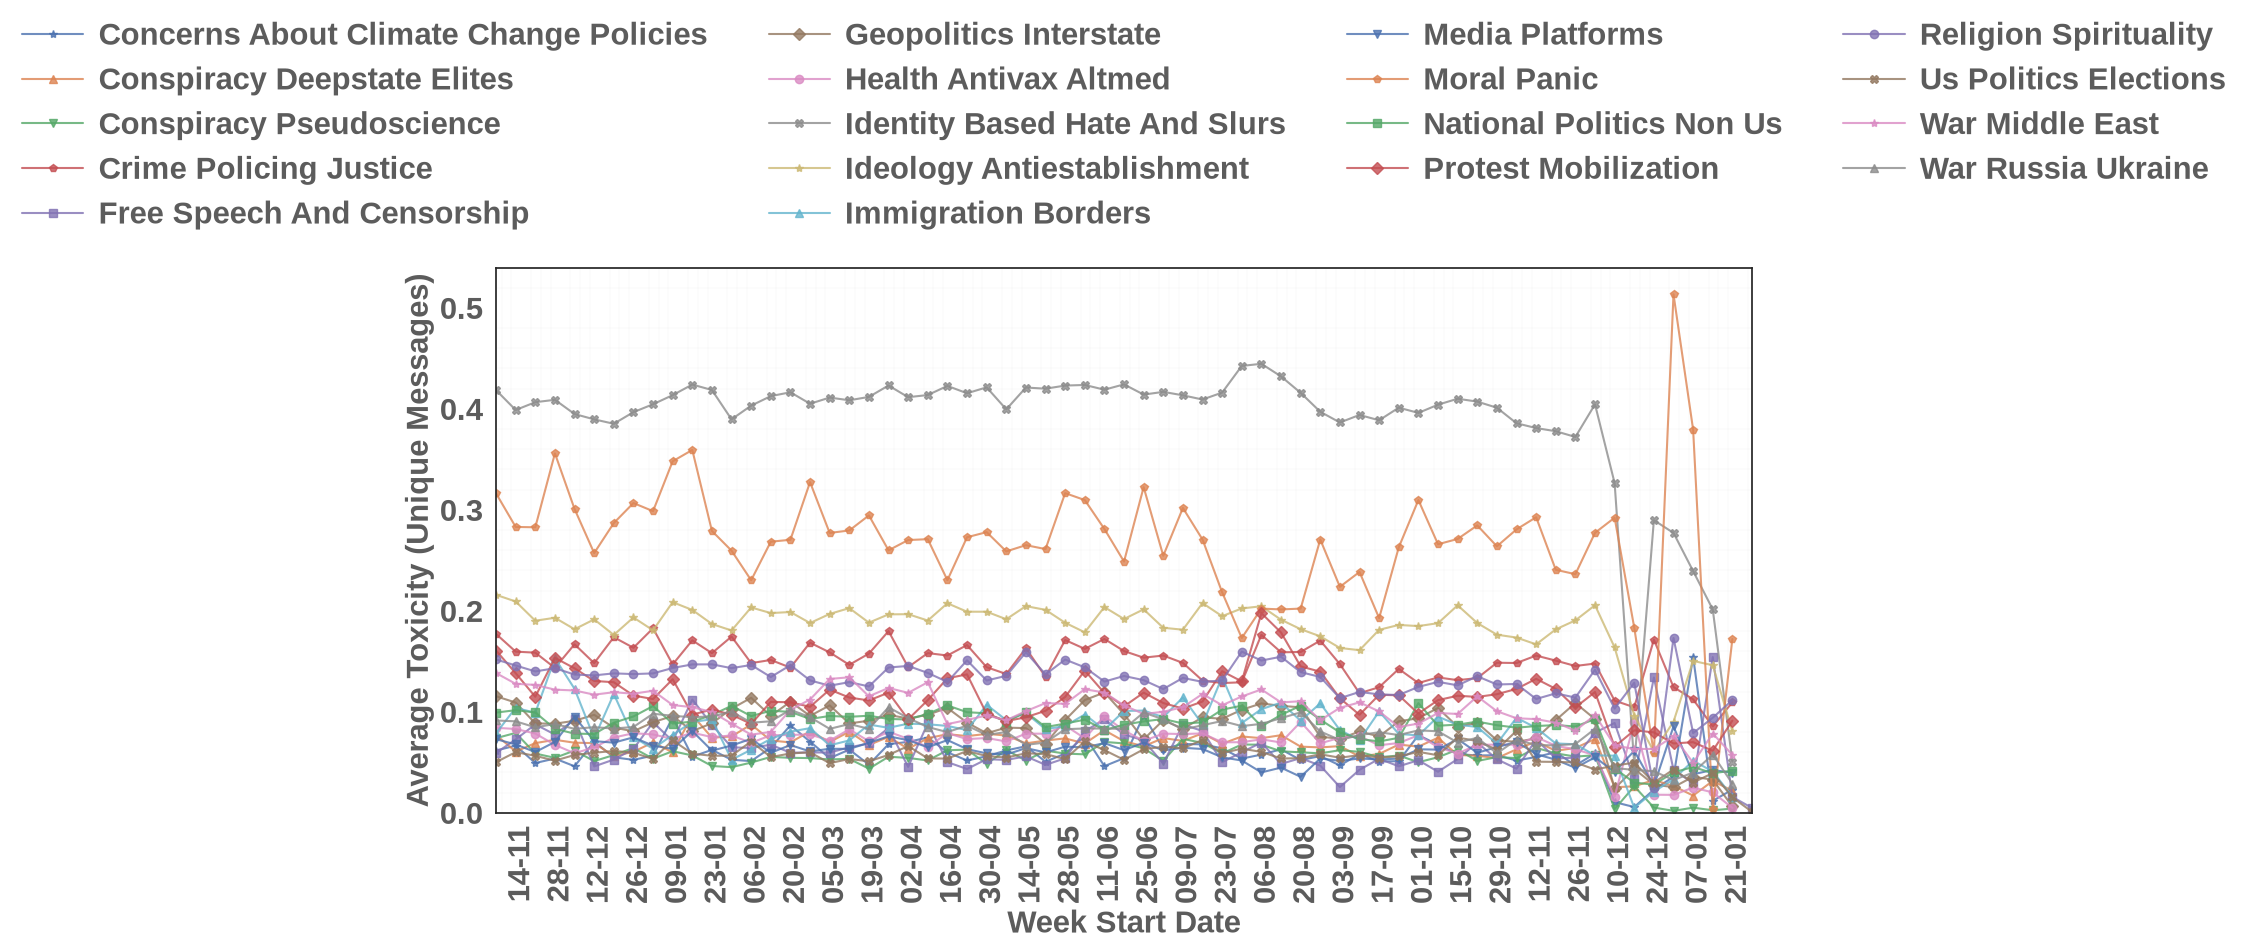

In [34]:
# 1. Preparação e Conversão
df_plot = df.copy()
df_plot["datetime"] = pd.to_datetime(df_plot["datetime"], errors="coerce")
df_plot = df_plot.dropna(subset=["datetime", "toxicity", "macro_topic_norm"])

# 2. Desduplicação (mensagens únicas por id + group_name)
df_unique = df_plot.drop_duplicates(subset=["datetime", "macro_topic_norm", "id", "group_name"])

# 3. Média de toxicidade por semana (mesmo Grouper do gráfico de contagem)
df_weekly = (
    df_unique.groupby([pd.Grouper(key="datetime", freq="W"), "macro_topic_norm"])["toxicity"]
    .mean()
    .reset_index(name="toxicity_mean")
)

# 4. Pivot: cada tópico vira uma coluna (mesma ordem alfabética do outro gráfico)
df_pivot = df_weekly.pivot(index="datetime", columns="macro_topic_norm", values="toxicity_mean")

# 5. Estilos FIXOS por tópico (garante mesma cor/marcador nos dois gráficos)
markers = ['*', '^', 'v', 'p', 's', 'D', 'o', 'X']
default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# IMPORTANTE: use aqui a mesma lista de tópicos do gráfico de contagem
# (ex.: sorted(df["macro_topic_norm"].dropna().unique()))
all_topics = sorted(df["macro_topic_norm"].dropna().unique())
topic_style = {
    t: {"color": default_colors[i % len(default_colors)],
        "marker": markers[i % len(markers)]}
    for i, t in enumerate(all_topics)
}

# 6. Figura
fig, ax = plt.subplots(figsize=(20, 10))

for column in df_pivot.columns:
    s = topic_style[column]
    serie = df_pivot[column].dropna()  # evita quebrar a linha em semanas sem dados
    ax.plot(
        serie.index,
        serie.values,
        marker=s["marker"],
        color=s["color"],
        linestyle='-',
        linewidth=1.5,
        markersize=6,
        alpha=0.8,
        label=column
    )

# 7. Eixo X (igual ao outro gráfico)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=90)

# 8. Estilização
ax.set_xlabel('Week Start Date')
ax.set_ylabel('Average Toxicity (Unique Messages)')

ax.minorticks_on()
ax.grid(True, which='minor', linestyle='-', linewidth=0.25, alpha=0.35)
ax.set_xlim(df_pivot.index.min(), df_pivot.index.max())
ax.set_ylim(bottom=0)

# 9. Legenda
ax.legend(
    loc='lower center',
    bbox_to_anchor=(0.5, 1.02),
    ncol=4,
    frameon=False,
    handletextpad=0.5
)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/toxicidade_media_semanal_combinada.png", format="png", bbox_inches='tight')
plt.show()

In [45]:
import pandas as pd

# 1. Definir as colunas de interesse do Detoxify
detox_cols = ['toxicity', 'severe_toxicity', 'obscene', 'threat', 'insult', 'identity_attack']

# 2. Agrupar pelo macrotópico e calcular média (mean) e desvio padrão (std)
df_agg = df.groupby('macro_topic_norm')[detox_cols].agg(['mean', 'std'])

# 3. Criar um novo DataFrame vazio para receber o texto formatado
df_tabela = pd.DataFrame(index=df_agg.index)

# 4. Juntar média e desvio padrão em uma única string formatada (com 4 casas decimais)
for col in detox_cols:
    media = df_agg[(col, 'mean')]
    desvio = df_agg[(col, 'std')]
    df_tabela[col] = media.map("{:.2f}".format) + " ± " + desvio.map("{:.2f}".format)

# Reseta o index para o nome do tópico virar uma coluna normal
df_tabela = df_tabela.reset_index()

# 5. Exibir a tabela no Jupyter
display(df_tabela)

,macro_topic_norm,toxicity,severe_toxicity,obscene,threat,insult,identity_attack
0,Concerns About Climate Change Policies,0.06 ± 0.17,0.00 ± 0.02,0.02 ± 0.11,0.00 ± 0.02,0.01 ± 0.08,0.00 ± 0.04
1,Conspiracy Deepstate Elites,0.07 ± 0.17,0.00 ± 0.02,0.02 ± 0.11,0.00 ± 0.02,0.01 ± 0.07,0.01 ± 0.05
2,Conspiracy Pseudoscience,0.06 ± 0.18,0.00 ± 0.02,0.02 ± 0.11,0.00 ± 0.02,0.01 ± 0.08,0.00 ± 0.04
3,Crime Policing Justice,0.15 ± 0.26,0.01 ± 0.03,0.04 ± 0.14,0.01 ± 0.07,0.03 ± 0.10,0.02 ± 0.09
4,Free Speech And Censorship,0.06 ± 0.16,0.00 ± 0.02,0.02 ± 0.09,0.00 ± 0.03,0.01 ± 0.07,0.01 ± 0.05
5,Geopolitics Interstate,0.09 ± 0.22,0.00 ± 0.04,0.03 ± 0.13,0.01 ± 0.05,0.02 ± 0.10,0.02 ± 0.08
6,Health Antivax Altmed,0.07 ± 0.18,0.00 ± 0.02,0.02 ± 0.10,0.01 ± 0.04,0.01 ± 0.07,0.00 ± 0.03
7,Identity Based Hate And Slurs,0.41 ± 0.38,0.04 ± 0.13,0.15 ± 0.28,0.02 ± 0.08,0.15 ± 0.26,0.21 ± 0.29
8,Ideology Antiestablishment,0.19 ± 0.31,0.01 ± 0.06,0.07 ± 0.21,0.01 ± 0.05,0.06 ± 0.17,0.03 ± 0.11
9,Immigration Borders,0.09 ± 0.21,0.00 ± 0.04,0.03 ± 0.12,0.00 ± 0.03,0.02 ± 0.10,0.02 ± 0.08


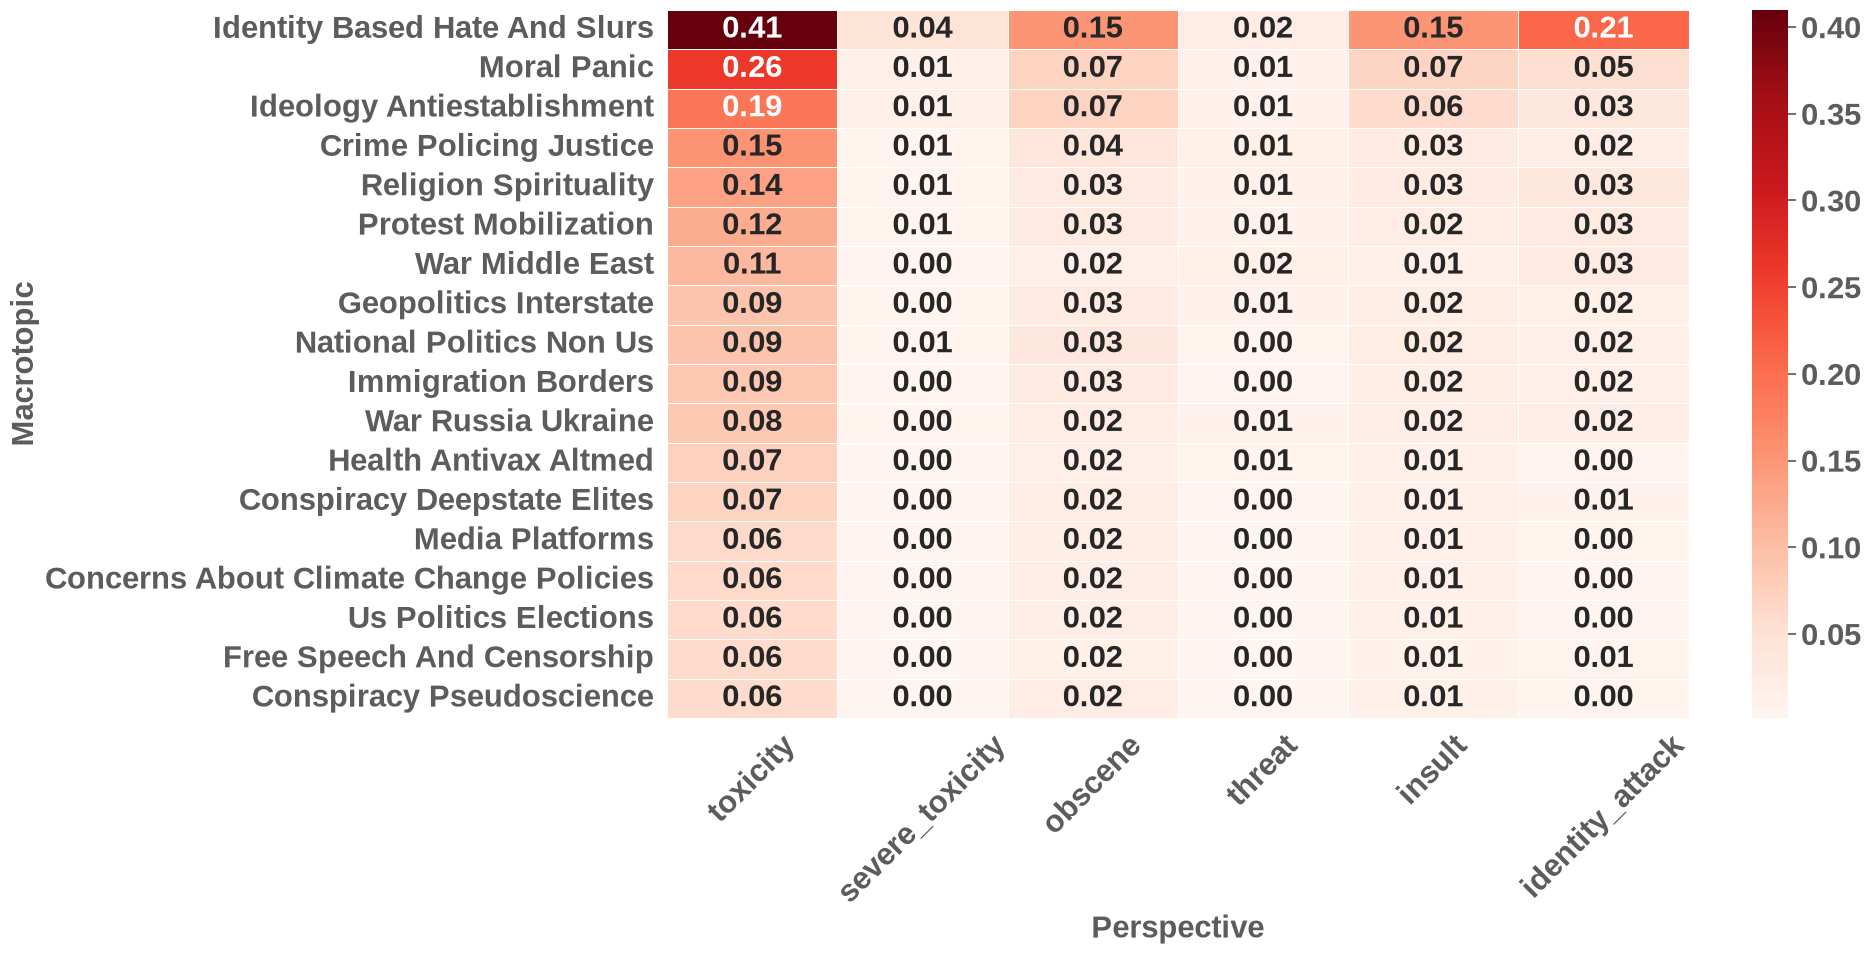

In [52]:
detox_cols = ['toxicity', 'severe_toxicity', 'obscene', 'threat', 'insult', 'identity_attack']
# Cria um dataframe apenas com as médias das 6 colunas, ordenado pelo tópico mais tóxico
df_medias = df.groupby('macro_topic_norm')[detox_cols].mean().loc[ordem_decrescente]

plt.figure(figsize=(20, 10))
sns.heatmap(df_medias, annot=True, fmt=".2f", cmap="Reds", linewidths=.5)
plt.ylabel('Macrotopic')
plt.xlabel('Perspective')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/heat_map_toxicidade_media.png", format="png", bbox_inches='tight')
plt.show()